In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

print("All imports successful!")


All imports successful!


In [7]:
# ── Config ───────────────────────────────────────────────────
IMG_SIZE        = (224, 224)
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 10
EPOCHS_FINETUNE = 20
LR_FROZEN       = 1e-3
LR_FINETUNE     = 1e-5

MODEL_DIR  = Path("../models")
RESULT_DIR = Path("../results")
SPLIT_DIR  = Path("../data/PlantVillage_split")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

class_names = np.load(MODEL_DIR / "class_names.npy", allow_pickle=True)
class_weights = np.load(MODEL_DIR / "class_weights.npy")
NUM_CLASSES = len(class_names)

print(f"Number of classes: {NUM_CLASSES}")


Number of classes: 15


In [13]:
# ── Generators ───────────────────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    fill_mode="nearest"
)

test_val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    SPLIT_DIR / "train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

val_gen = test_val_datagen.flow_from_directory(
    SPLIT_DIR / "val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_gen = test_val_datagen.flow_from_directory(
    SPLIT_DIR / "test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Data generators created successfully!")
print(f"Training samples: {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples: {test_gen.samples}")

assert train_gen.class_indices == val_gen.class_indices == test_gen.class_indices, "Class mismatch across splits!"
assert list(train_gen.class_indices.keys()) == list(class_names), "Class order mismatch with saved class_names.npy"

class_weight_dict = {i: float(w) for i, w in enumerate(class_weights)}


Found 14440 images belonging to 15 classes.
Found 3097 images belonging to 15 classes.
Found 3101 images belonging to 15 classes.
Data generators created successfully!
Training samples: 14440
Validation samples: 3097
Test samples: 3101


In [14]:
# ── Build Model ──────────────────────────────────────────────
def build_transfer_model(num_classes):
    base = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )
    base.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="efficientnet_b0")
    return model, base

tl_model, base_model = build_transfer_model(NUM_CLASSES)
tl_model.summary()

Model: "efficientnet_b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,845,746 (18.49 MB)

 Trainable params: 793,615 (3.03 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [15]:
# ── Phase 1: Train Head ──────────────────────────────────────
tl_model.compile(
    optimizer=Adam(learning_rate=LR_FROZEN),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cb_p1 = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        MODEL_DIR / "tl_phase1_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    callbacks.CSVLogger(str(RESULT_DIR / "tl_phase1_log.csv"))
]

history_p1 = tl_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=cb_p1,
    class_weight=class_weight_dict,
    verbose=1
)

print("Phase 1 training complete!")


Epoch 1/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.1096 - loss: 2.8474
Epoch 1: val_accuracy improved from None to 0.15531, saving model to ..\models\tl_phase1_best.keras

Epoch 1: finished saving model to ..\models\tl_phase1_best.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 179s 382ms/step - accuracy: 0.1215 - loss: 2.6984 - val_accuracy: 0.1553 - val_loss: 2.6808
Epoch 2/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.1368 - loss: 2.5904
Epoch 2: val_accuracy did not improve from 0.15531
452/452 ━━━━━━━━━━━━━━━━━━━━ 157s 348ms/step - accuracy: 0.1468 - loss: 2.5799 - val_accuracy: 0.1553 - val_loss: 2.6590
Epoch 3/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.1510 - loss: 2.5738
Epoch 3: val_accuracy did not improve from 0.15531
452/452 ━━━━━━━━━━━━━━━━━━━━ 156s 345ms/step - accuracy: 0.1517 - loss: 2.5643 - val_accuracy: 0.1553 - val_loss: 2.6433
Epoch 4/10
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.1550 - loss: 2.5459
Epoch 4: val_accu

In [16]:
# ── Phase 2: Fine-tune ───────────────────────────────────────
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=Adam(learning_rate=LR_FINETUNE),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cb_p2 = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        MODEL_DIR / "tl_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    callbacks.CSVLogger(str(RESULT_DIR / "tl_phase2_log.csv"))
]

history_p2 = tl_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    callbacks=cb_p2,
    class_weight=class_weight_dict,
    verbose=1
)

print("Phase 2 training complete!")


Epoch 1/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.1551 - loss: 2.5204
Epoch 1: val_accuracy improved from None to 0.15531, saving model to ..\models\tl_best.keras

Epoch 1: finished saving model to ..\models\tl_best.keras
452/452 ━━━━━━━━━━━━━━━━━━━━ 177s 376ms/step - accuracy: 0.1555 - loss: 2.5459 - val_accuracy: 0.1553 - val_loss: 2.6117 - learning_rate: 1.0000e-05
Epoch 2/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.1547 - loss: 2.5292
Epoch 2: val_accuracy did not improve from 0.15531
452/452 ━━━━━━━━━━━━━━━━━━━━ 173s 383ms/step - accuracy: 0.1554 - loss: 2.5430 - val_accuracy: 0.1553 - val_loss: 2.6116 - learning_rate: 1.0000e-05
Epoch 3/20
452/452 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 0.1541 - loss: 2.5384
Epoch 3: val_accuracy did not improve from 0.15531
452/452 ━━━━━━━━━━━━━━━━━━━━ 166s 368ms/step - accuracy: 0.1555 - loss: 2.5369 - val_accuracy: 0.1553 - val_loss: 2.6116 - learning_rate: 1.0000e-05
Epoch 4/20
452/452 ━━━━━━━━━━━━━━━━

In [17]:
# ── Save Final Model ─────────────────────────────────────────
tl_model.save(MODEL_DIR / "tl_final.keras")
print("Saved → models/tl_final.keras")

Saved → models/tl_final.keras


In [18]:
# ── Combine History ──────────────────────────────────────────
combined_history = {}
for k in history_p1.history:
    p1_vals = [float(v) for v in history_p1.history[k]]
    p2_vals = [float(v) for v in history_p2.history.get(k, [])]
    combined_history[k] = p1_vals + p2_vals

with open(RESULT_DIR / "tl_history.json", "w") as f:
    json.dump(combined_history, f)

print("Saved → results/tl_history.json")

Saved → results/tl_history.json


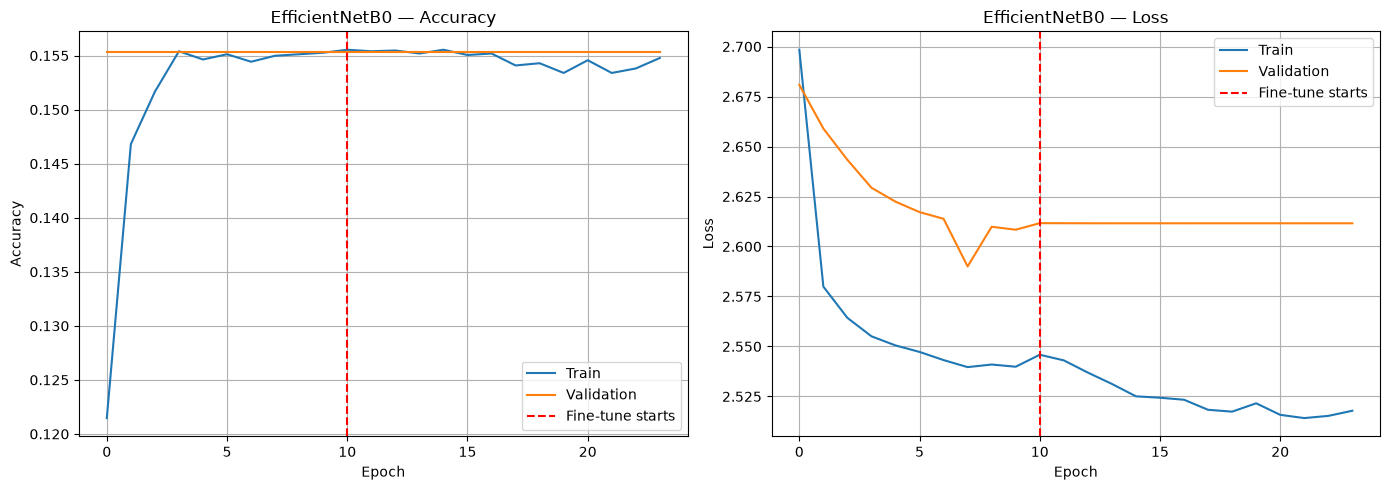

Saved → results/tl_training_curves.png


In [19]:
# ── Plot Curves ──────────────────────────────────────────────
total_p1 = len(history_p1.history["accuracy"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(combined_history["accuracy"], label="Train")
axes[0].plot(combined_history["val_accuracy"], label="Validation")
axes[0].axvline(x=total_p1, color="red", linestyle="--", label="Fine-tune starts")
axes[0].set_title("EfficientNetB0 — Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(combined_history["loss"], label="Train")
axes[1].plot(combined_history["val_loss"], label="Validation")
axes[1].axvline(x=total_p1, color="red", linestyle="--", label="Fine-tune starts")
axes[1].set_title("EfficientNetB0 — Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(RESULT_DIR / "tl_training_curves.png", dpi=150)
plt.show()

print("Saved → results/tl_training_curves.png")

97/97 ━━━━━━━━━━━━━━━━━━━━ 23s 237ms/step - accuracy: 0.1554 - loss: 2.6113
Test results: [2.6112828254699707, 0.15543372929096222]
97/97 ━━━━━━━━━━━━━━━━━━━━ 23s 226ms/step

Classification Report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.00      0.00      0.00       150
                     Pepper__bell___healthy       0.00      0.00      0.00       222
                      Potato___Early_blight       0.00      0.00      0.00       150
                       Potato___Late_blight       0.00      0.00      0.00       150
                           Potato___healthy       0.00      0.00      0.00        23
                      Tomato_Bacterial_spot       0.00      0.00      0.00       320
                        Tomato_Early_blight       0.00      0.00      0.00       150
                         Tomato_Late_blight       0.00      0.00      0.00       287
                           Tomato_Le

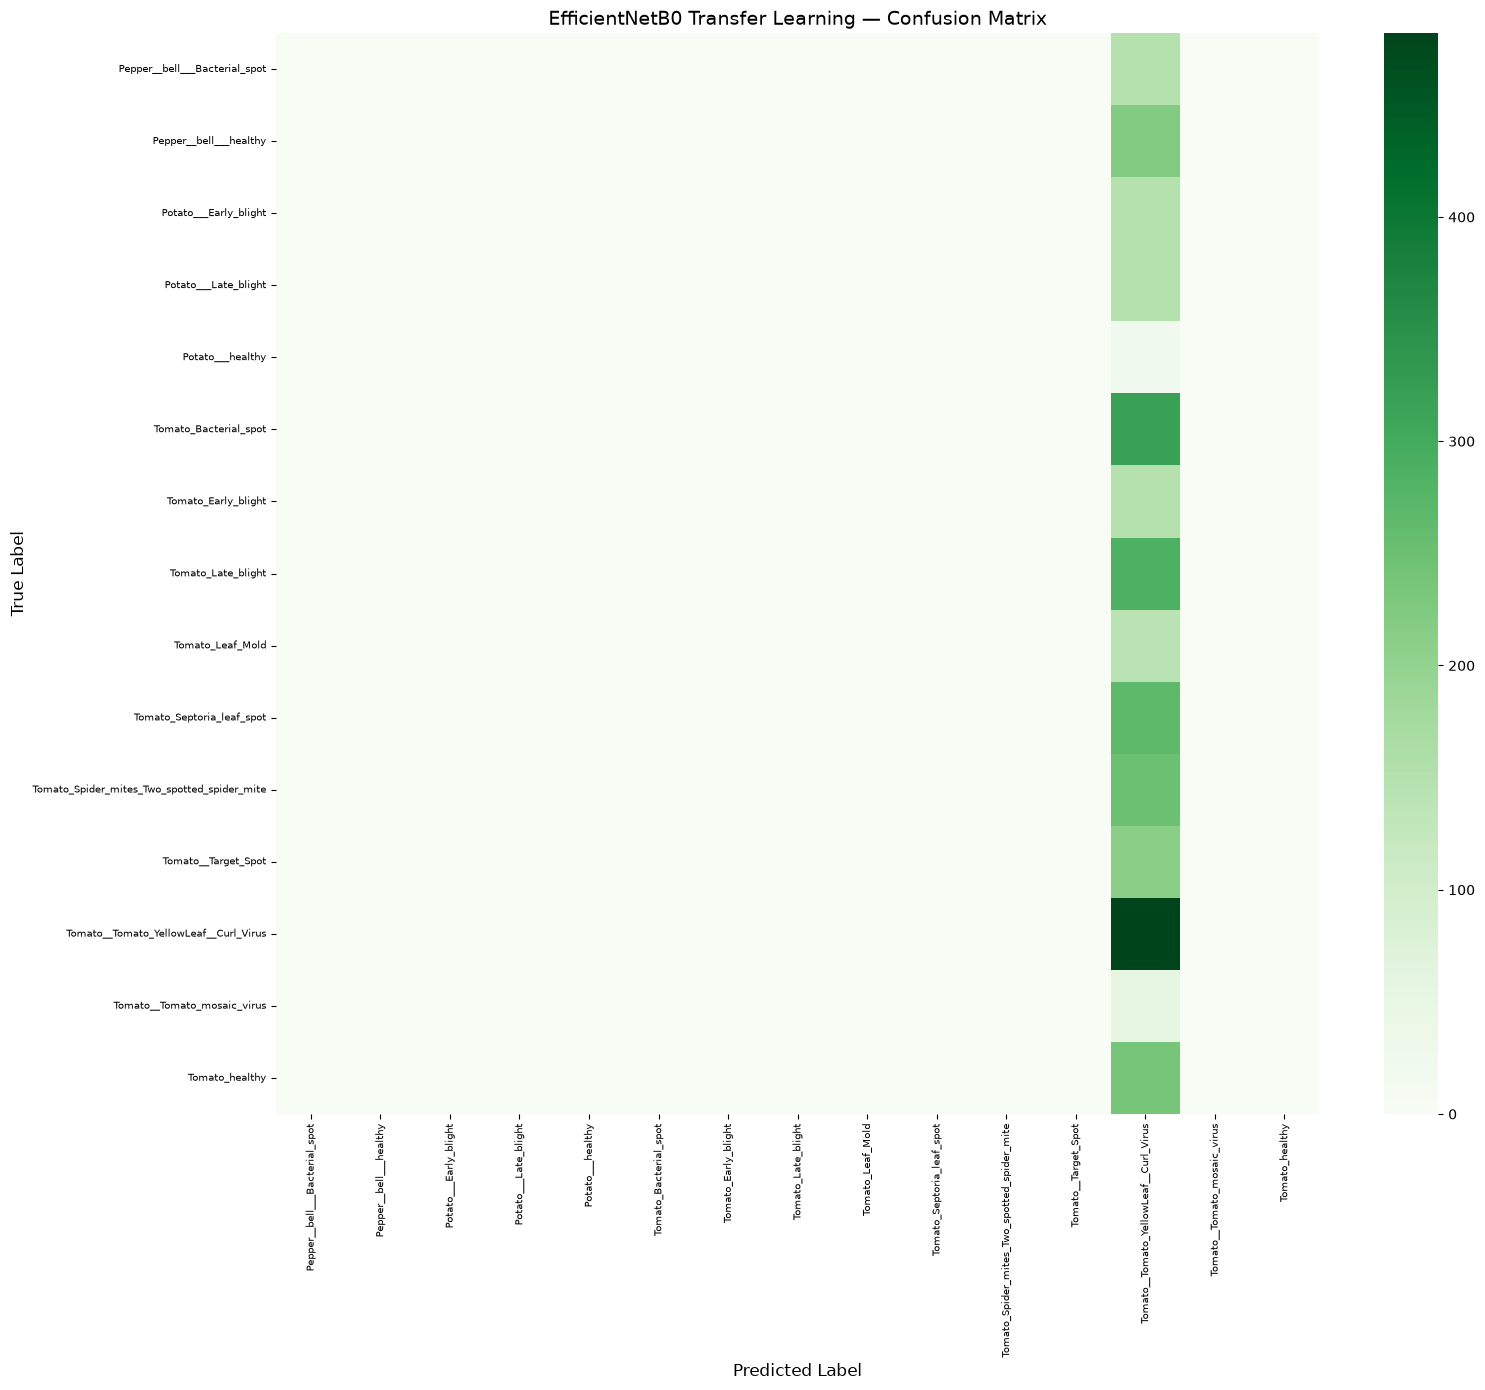

Saved → results/tl_confusion_matrix.png
Transfer learning complete


In [20]:
# ── Evaluation ───────────────────────────────────────────────
test_gen.reset()
results = tl_model.evaluate(test_gen, verbose=1)
print("Test results:", results)

test_gen.reset()
pred_probs = tl_model.predict(test_gen, verbose=1)
y_pred_tl = np.argmax(pred_probs, axis=1)
y_true = test_gen.classes

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred_tl,
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred_tl)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=False,
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("EfficientNetB0 Transfer Learning — Confusion Matrix", fontsize=14)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(RESULT_DIR / "tl_confusion_matrix.png", dpi=150)
plt.show()

print("Saved → results/tl_confusion_matrix.png")
print("Transfer learning complete")